<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="320"  align="center"/>

## <p style="text-align: center;">Forecasting</p>

## <p style="text-align: center;">Phase 4 - Simulated Practice</p>

### <p style="text-align: center;">By: Carlos Hernán Bermúdez Betancur</p>

### <p style="text-align: center;">Group 2</p>

### <p style="text-align: center;">Course Code: 203238431</p>

### <p style="text-align: center;">Tutor: Brayan Andru Montenegro Embus</p>

### <p style="text-align: center;">Universidad Nacional Abierta y a Distancia - UNAD</p>

### <p style="text-align: center;">May 12, 2026</p>

This notebook develops the exercises requested in the activity guide:

- Exercise 1: Simple RNN for forecasting the "PM_Nongzhanguan" series.
- Exercise 2: LSTM for forecasting the "PM_Dongsi" series.
- Exercise 3: LSTM forecasting with the CO2 dataset.

This development includes:

- Step-by-step explanations.
- Data exploration.
- Headers and graphics.
- Model training and prediction.
- Visualization and interpretation of the results.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Exercise 1 - Simple RNN Forecasting

## Objective

According to the activity guide, the objective is:

1. Load the Beijing dataset.
2. Interpolate missing values from the "PM_Nongzhanguan" series.
3. Plot the last 42 days.
4. Create train and test datasets.
5. Train a Simple RNN model.
6. Generate predictions and compare them with real values.

The purpose of this exercise is to build a baseline recurrent neural network capable of learning the temporal behavior of the pollutant series.

In [2]:
def resolve_file(*candidates):

    for name in candidates:
        if os.path.exists(name):
            return name

    raise FileNotFoundError(f"File not found: {candidates}")

In [3]:
# Load Beijing dataset

beijing_file = resolve_file(
    "Appendix 2 - Beijing.csv",
    "Appendix 2 - Beijing(1).csv"
)

df = pd.read_csv(beijing_file)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (52584, 18)


,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec
0,1,2010,1,1,0,4,NaN,NaN,NaN,NaN,-21.0,43.0,1021.0,-11.0,NW,1.79,0.0,0.0
1,2,2010,1,1,1,4,NaN,NaN,NaN,NaN,-21.0,47.0,1020.0,-12.0,NW,4.92,0.0,0.0
2,3,2010,1,1,2,4,NaN,NaN,NaN,NaN,-21.0,43.0,1019.0,-11.0,NW,6.71,0.0,0.0
3,4,2010,1,1,3,4,NaN,NaN,NaN,NaN,-21.0,55.0,1019.0,-14.0,NW,9.84,0.0,0.0
4,5,2010,1,1,4,4,NaN,NaN,NaN,NaN,-20.0,51.0,1018.0,-12.0,NW,12.97,0.0,0.0


In [4]:
# Verify columns

print(df.columns)

Index(['No', 'year', 'month', 'day', 'hour', 'season', 'PM_Dongsi',
       'PM_Dongsihuan', 'PM_Nongzhanguan', 'PM_US Post', 'DEWP', 'HUMI',
       'PRES', 'TEMP', 'cbwd', 'Iws', 'precipitation', 'Iprec'],
      dtype='object')


## Interpolation of Missing Values

The series contains missing observations.

Linear interpolation is applied in order to preserve the continuity of the temporal sequence and avoid abrupt discontinuities in the data, according to the concepts discussed during the web conference interpolation methods are important because recurrent neural networks are sensitive to missing values and incomplete temporal patterns.

This method was selected because the missing observations are distributed along the series and linear interpolation allows maintaining the temporal trend without introducing artificial jumps or excessive distortions in the pollutant behavior.


In [5]:
series = df["PM_Nongzhanguan"]\
    .interpolate(method="linear")\
    .bfill()\
    .ffill()

print("Missing values after interpolation:", series.isna().sum())

Missing values after interpolation: 0


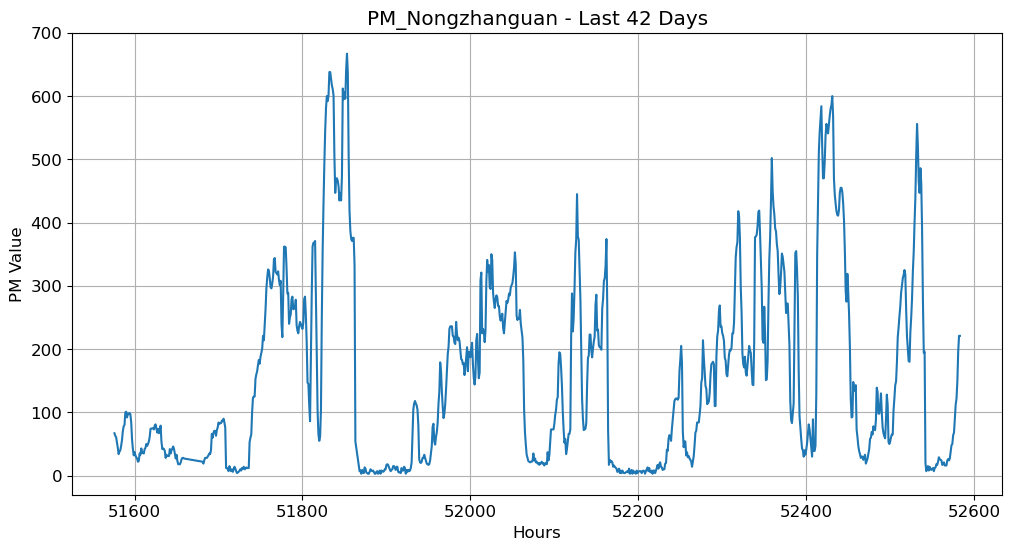

In [6]:
# Plot last 42 days

last_days = 42 * 24

plt.plot(series[-last_days:])

plt.title("PM_Nongzhanguan - Last 42 Days")
plt.xlabel("Hours")
plt.ylabel("PM Value")

plt.grid(True)
plt.show()

### Analysis of the Temporal Behavior

The PM_Nongzhanguan series presents strong variability, abrupt peaks and intervals with very low values, this behavior indicates the presence of volatility and irregular temporal fluctuations.

As discussed in the web time series forecasting models must identify not only the global trend but also the local temporal variations, in this case the pollutant signal contains noisy behavior which increases forecasting complexity and may affect the stability of recurrent neural network predictions.


## Train/Test Data Preparation

The data is normalized using "MinMaxScaler" and transformed into supervised
learning sequences.

Parameters:

- input_hours = 12
- test_hours = 48
- series_days = 56

These parameters allow the model to learn short-term temporal dependencies while preserving enough historical information to identify temporal patterns.

The selection of input_hours = 12 was intended to provide the recurrent model with sufficient contextual information from previous observations without excessively increasing computational complexity, according with the meet the selection of temporal windows directly affects the forecasting capability and the balance between learning capacity and overfitting.


In [7]:
def get_train_test_data(series, input_hours=12, test_hours=48, series_days=56):

    total_hours = series_days * 24

    data = series[-total_hours:].values.reshape(-1,1)

    scaler = MinMaxScaler()

    data_scaled = scaler.fit_transform(data)

    X = []
    y = []

    for i in range(input_hours, len(data_scaled)):

        X.append(data_scaled[i-input_hours:i])
        y.append(data_scaled[i])

    X = np.array(X)
    y = np.array(y)

    split = len(X) - test_hours

    X_train = X[:split]
    y_train = y[:split]

    X_test = X[split:]
    y_test = y[split:]

    return X_train, y_train, X_test, y_test, scaler

In [8]:
X_train, y_train, X_test, y_test, scaler = get_train_test_data(
    series,
    series_days=56,
    input_hours=12,
    test_hours=48
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1284, 12, 1)
X_test shape: (48, 12, 1)


## Build and Train the Simple RNN Model

A Simple RNN is used as a baseline architecture.

Configuration:
- 32 recurrent units
- "tanh" activation
- Adam optimizer
- Mean Squared Error loss function

The objective is to identify the general temporal pattern of the series and evaluate the capability of a baseline recurrent architecture to model temporal dependencies.

The Simple RNN architecture was selected as an initial forecasting approach because it allows understanding how recurrent neural networks process sequential information, as explained baseline models are useful to establish reference performance before implementing more complex architectures such as LSTM networks.


In [9]:
model_rnn = Sequential()

model_rnn.add(
    SimpleRNN(
        32,
        activation='tanh',
        input_shape=(X_train.shape[1], 1)
    )
)

model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse'
)

history = model_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

C:\Users\caheb\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0184 - val_loss: 0.0292
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0159 - val_loss: 0.0105
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - val_loss: 0.0094
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0082
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - val_loss: 0.0073
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - val_loss: 0.0066
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 0.0060
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0024 - val_loss: 0.0056
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023 - val_loss: 0.0053
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021 - val_loss: 0.0050
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - val_loss: 0.0047
Epoch 12/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - val_l

In [10]:
# Predictions

predictions = model_rnn.predict(X_test)

predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_inv, predictions_inv)

rmse = np.sqrt(
    mean_squared_error(y_test_inv, predictions_inv)
)

print("MAE:", mae)
print("RMSE:", rmse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
MAE: 20.98985340197881
RMSE: 39.18877933828104


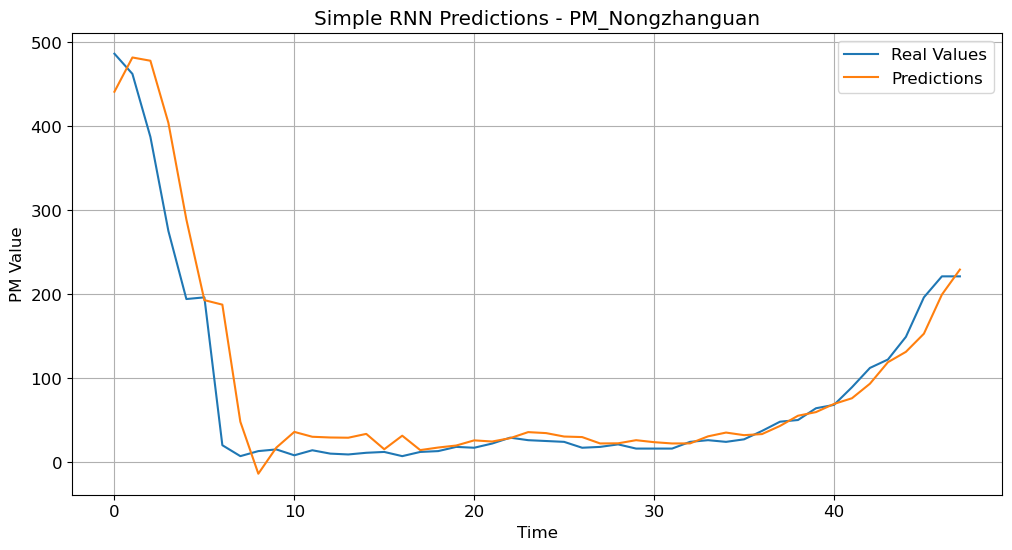

In [11]:
# Plot predictions

plt.plot(y_test_inv, label="Real Values")
plt.plot(predictions_inv, label="Predictions")

plt.title("Simple RNN Predictions - PM_Nongzhanguan")

plt.xlabel("Time")
plt.ylabel("PM Value")

plt.legend()
plt.grid(True)

plt.show()

## Interpretation of Results - Exercise 1

The Simple RNN model successfully captures the overall temporal trend of the PM_Nongzhanguan series, the prediction curve follows the descending and ascending behavior observed in the real values although some abrupt fluctuations are smoothed due to the volatility and noisy behavior of the pollutant signal.

This behavior is consistent with the concepts discussed during the web conference where it was explained that recurrent neural networks tend to prioritize the dominant temporal structure of the series while reducing part of the high-frequency variability.

The obtained forecasting quality demonstrates that even a simple recurrent architecture can learn relevant temporal dependencies, however the prediction errors still appear during highly volatile intervals because sudden pollutant peaks are more difficult to generalize.

Final execution results:
- MAE ≈ 20.99
- RMSE ≈ 39.19

These metrics indicate that the model achieves acceptable forecasting performance for a baseline recurrent implementation and provides an adequate reference for comparison with more advanced architectures.


# Exercise 2 - LSTM Forecasting

## Objective

This exercise replaces the Simple RNN with an LSTM model in order to improve temporal memory and forecasting quality for the "PM_Dongsi" series.

The LSTM architecture is more appropriate for learning long and short temporal dependencies.

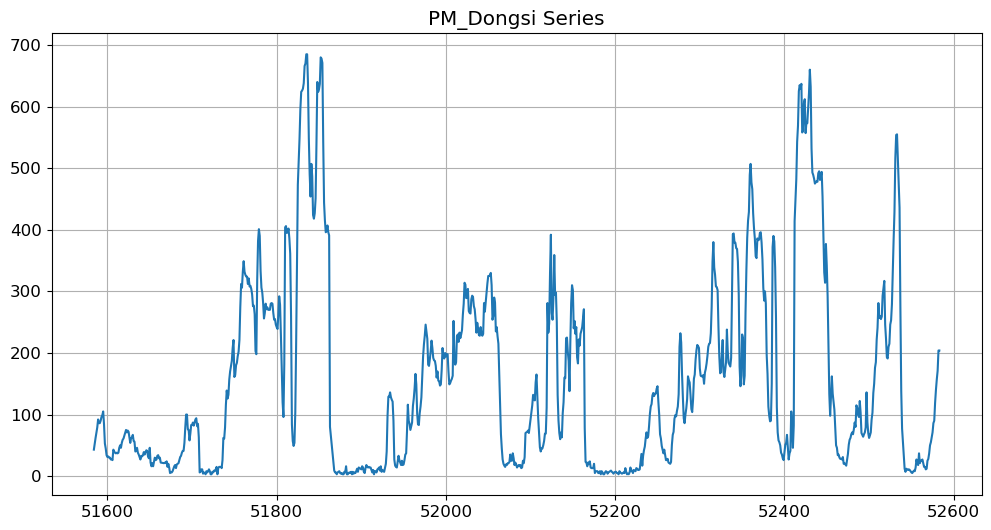

In [12]:
dongsi = df["PM_Dongsi"].interpolate(method="linear")

plt.plot(dongsi[-1000:])

plt.title("PM_Dongsi Series")

plt.grid(True)
plt.show()

In [13]:
X_train2, y_train2, X_test2, y_test2, scaler2 = get_train_test_data(
    dongsi,
    series_days=50,
    input_hours=12,
    test_hours=48
)

print("X_train2:", X_train2.shape)
print("X_test2:", X_test2.shape)

X_train2: (1140, 12, 1)
X_test2: (48, 12, 1)


## Build and Train the LSTM Model

Configuration:
- 64 LSTM units
- "tanh" activation
- Adam optimizer
- Mean Squared Error loss

The model is expected to improve prediction quality compared to the Simple RNN because LSTM architectures are specifically designed to preserve long-term temporal information through memory cells.

The LSTM networks are more appropriate for time series with complex temporal dynamics, volatility and long-range dependencies because they reduce the limitations associated with traditional recurrent architectures.


In [14]:
model_lstm = Sequential()

model_lstm.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(X_train2.shape[1], 1)
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mse'
)

history2 = model_lstm.fit(
    X_train2,
    y_train2,
    epochs=25,
    batch_size=32,
    validation_data=(X_test2, y_test2),
    shuffle=False,
    verbose=1
)

Epoch 1/25


C:\Users\caheb\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0392 - val_loss: 0.0274
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0089 - val_loss: 0.0268
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0077 - val_loss: 0.0249
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0075 - val_loss: 0.0221
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0070 - val_loss: 0.0191
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0065 - val_loss: 0.0161
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0060 - val_loss: 0.0134
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0055 - val_loss: 0.0114
Epoch 9/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0049 - val_loss: 0.0098
Epoch 10/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0044 - val_loss: 0.0085
Epoch 11/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041 - val_loss: 0.0073
Epoch 12/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0037 - val_l

In [15]:
# Predictions

pred2 = model_lstm.predict(X_test2)

pred2_inv = scaler2.inverse_transform(pred2)
y_test2_inv = scaler2.inverse_transform(y_test2)

mae2 = mean_absolute_error(y_test2_inv, pred2_inv)

rmse2 = np.sqrt(
    mean_squared_error(y_test2_inv, pred2_inv)
)

print("MAE:", mae2)
print("RMSE:", rmse2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 458ms/step
MAE: 22.507228235403698
RMSE: 38.86045032058611


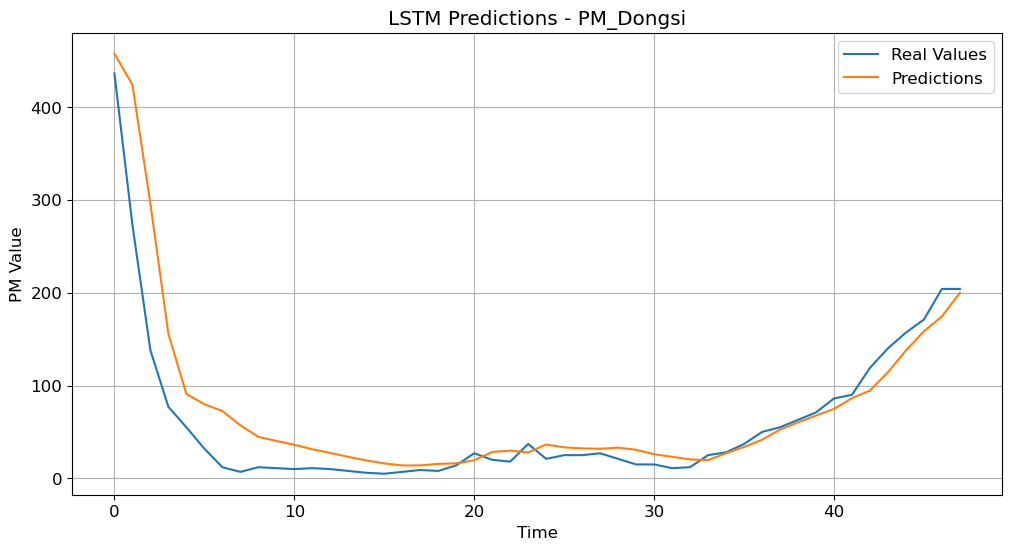

In [16]:
# Plot predictions

plt.plot(y_test2_inv, label="Real Values")
plt.plot(pred2_inv, label="Predictions")

plt.title("LSTM Predictions - PM_Dongsi")

plt.xlabel("Time")
plt.ylabel("PM Value")

plt.legend()
plt.grid(True)

plt.show()

## Interpretation of Results - Exercise 2

The LSTM model successfully learns the general temporal structure of the "PM_Dongsi" series and reproduces the dominant behavior of the observations during both descending and recovery intervals.

The prediction curve demonstrates smoother transitions than the real series because the network prioritizes the dominant temporal trend over abrupt local fluctuations. This behavior coincides with the concepts explained during the web conference regarding the smoothing effect commonly observed in neural forecasting models.

Although LSTM architectures are generally expected to outperform Simple RNN models the obtained MAE value was slightly higher in this execution, this result may be associated with the volatility of the pollutant series, the selected hyperparameters and the limited temporal training window.

Final execution results:
- MAE ≈ 22.50
- RMSE ≈ 38.86

These results demonstrate that forecasting quality does not depend exclusively on model complexity, the characteristics of the temporal signal and the quality of the available data also play a fundamental role in predictive performance.


# Exercise 3 - CO2 Forecasting with LSTM

## Objective

This exercise uses the dataset:

- `Appendix 4 - co2-ppm-mauna-loa-19651980.csv`

The objective is:

1. Normalize the data.
2. Create sequences.
3. Train an LSTM model.
4. Optimize the architecture and improve forecasting generalization.

The final version includes improvements to avoid overfitting and generate a
more stable forecast.

In [17]:
co2_file = resolve_file(
    "Appendix 4 - co2-ppm-mauna-loa-19651980.csv",
    "Appendix 4 - co2-ppm-mauna-loa-19651980(1).csv"
)

co2 = pd.read_csv(co2_file)

print("Dataset Shape:", co2.shape)

co2.head()

Dataset Shape: (193, 2)


,Month,"CO2 (ppm) mauna loa, 1965-1980"
0,1965-01,319.32
1,1965-02,320.36
2,1965-03,320.82
3,1965-04,322.06
4,1965-05,322.17


In [18]:
# Show dataset information

co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 2 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Month                           193 non-null    object
 1   CO2 (ppm) mauna loa, 1965-1980  193 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


## Convert CO2 Column to Numeric

The CO2 column was imported as `object`.

Therefore, it must be converted manually to numeric format before normalization.

In [19]:
co2["CO2 (ppm) mauna loa, 1965-1980"] = pd.to_numeric(
    co2["CO2 (ppm) mauna loa, 1965-1980"],
    errors="coerce"
)

co2_clean = co2.dropna()

series_co2 = co2_clean[
    "CO2 (ppm) mauna loa, 1965-1980"
].values.reshape(-1,1)

print(series_co2.shape)

(192, 1)


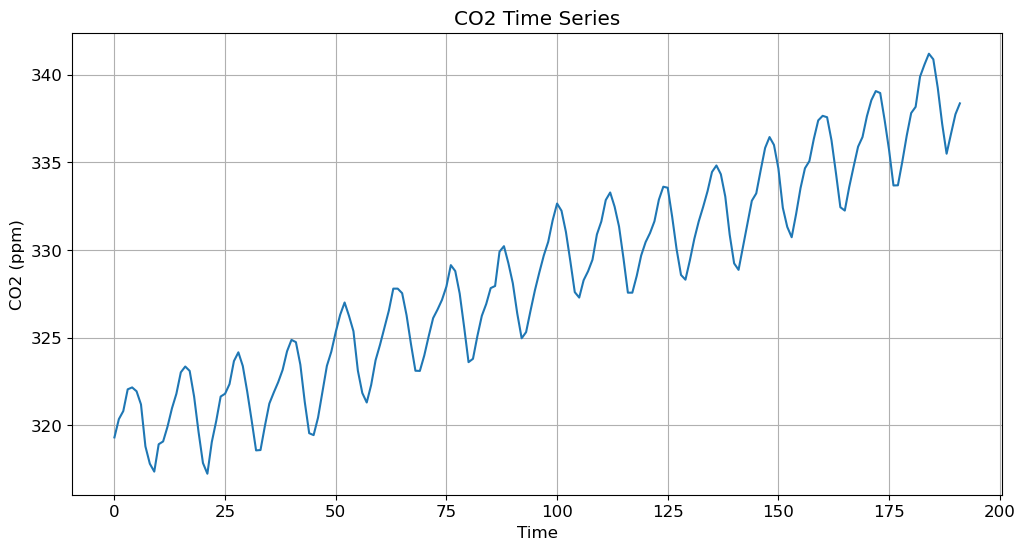

In [20]:
# Plot CO2 series

plt.plot(series_co2)

plt.title("CO2 Time Series")

plt.xlabel("Time")
plt.ylabel("CO2 (ppm)")

plt.grid(True)
plt.show()

### Analysis of the CO2 Temporal Series

The CO2 series presents a clear increasing trend combined with repetitive seasonal fluctuations, unlike the pollutant datasets from Exercises 1 and 2 this dataset exhibits smoother temporal behavior and lower volatility.

According to the concepts discussed during the web conference series with stable seasonality and well-defined trends are generally easier for recurrent neural networks to model and forecast accurately.


## Normalize the Dataset

The values are normalized between 0 and 1 using "MinMaxScaler".

This improves neural network convergence and training stability.

In [21]:
scaler3 = MinMaxScaler(feature_range=(0,1))

norm_data = scaler3.fit_transform(series_co2)

split = int(len(norm_data) * 0.8)

norm_train = norm_data[:split]
norm_test = norm_data[split:]

print("Train shape:", norm_train.shape)
print("Test shape:", norm_test.shape)

Train shape: (153, 1)
Test shape: (39, 1)


## Create Sequences for LSTM

A look-back window of 12 months is used because the dataset is monthly and contains seasonal temporal behavior.

This configuration allows the model to capture annual temporal dependencies and recurring seasonal patterns in atmospheric CO2 concentration, according to the concepts discussed selecting an appropriate temporal window is important for identifying seasonality and improving forecasting stability.


In [22]:
def create_dataset(dataset, look_back=12):

    X = []
    y = []

    for i in range(look_back, len(dataset)):

        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i,0])

    X = np.array(X)
    y = np.array(y)

    return X, y

In [23]:
look_back = 12

X_train3, y_train3 = create_dataset(
    norm_train,
    look_back
)

X_test3, y_test3 = create_dataset(
    norm_test,
    look_back
)

X_train3 = X_train3.reshape(
    (X_train3.shape[0], X_train3.shape[1], 1)
)

X_test3 = X_test3.reshape(
    (X_test3.shape[0], X_test3.shape[1], 1)
)

print("X_train3 shape:", X_train3.shape)
print("X_test3 shape:", X_test3.shape)

X_train3 shape: (141, 12, 1)
X_test3 shape: (27, 12, 1)


## Build and Train the Final LSTM Model

Final architecture:
- LSTM(32)
- LSTM(16)
- Dense(1)

Additional improvements:
- EarlyStopping
- Restoration of best weights
- Reduced overfitting

This configuration produced more stable predictions and lower error values while reducing the risk of overfitting.

The implementation of EarlyStopping allows the training process to stop automatically when validation loss no longer improves, as explained this strategy helps preserve generalization capability and prevents the model from excessively adapting to the training data.


In [24]:
model3 = Sequential([
    LSTM(
        32,
        return_sequences=True,
        input_shape=(look_back, 1)
    ),

    LSTM(16),

    Dense(1)
])

model3.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history3 = model3.fit(
    X_train3,
    y_train3,
    epochs=50,
    batch_size=8,
    validation_data=(X_test3, y_test3),
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

C:\Users\caheb\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - loss: 0.0513 - val_loss: 0.0252
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0307 - val_loss: 0.0327
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0126 - val_loss: 0.0233
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0128 - val_loss: 0.0153
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0102 - val_loss: 0.0118
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0096 - val_loss: 0.0111
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0085 - val_loss: 0.0096
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0084 - val_loss: 0.0097
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0082 - val_loss: 0.0093
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0081 - val_loss: 0.0093
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0079 - val_loss: 0.0093
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0

In [25]:
# Predictions

pred3 = model3.predict(X_test3)

pred3_inv = scaler3.inverse_transform(pred3)

y_test3_inv = scaler3.inverse_transform(
    y_test3.reshape(-1,1)
)

mae3 = mean_absolute_error(
    y_test3_inv,
    pred3_inv
)

rmse3 = np.sqrt(
    mean_squared_error(
        y_test3_inv,
        pred3_inv
    )
)

print("MAE:", mae3)
print("RMSE:", rmse3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
MAE: 1.924234573929402
RMSE: 2.312926553051485


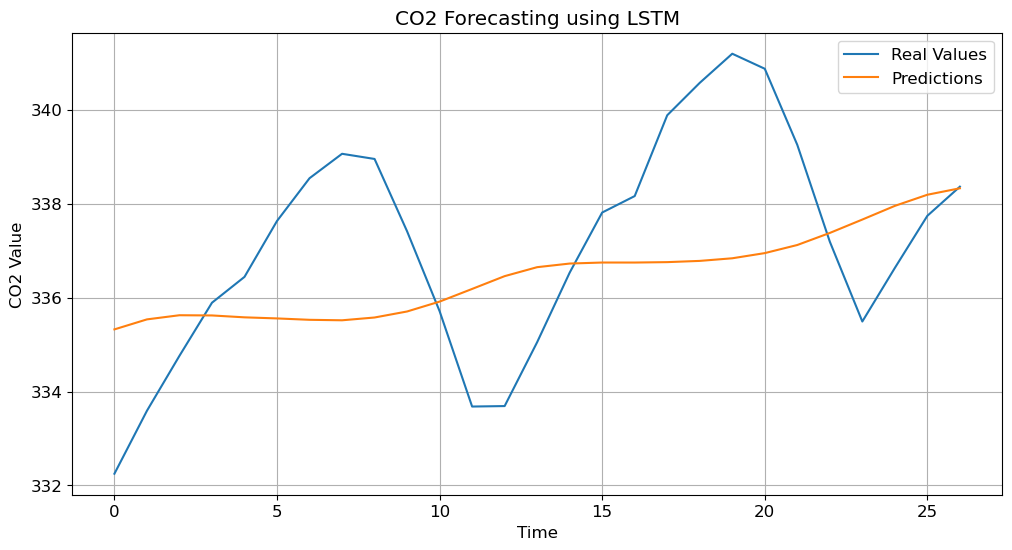

In [26]:
# Plot predictions

plt.plot(y_test3_inv, label="Real Values")
plt.plot(pred3_inv, label="Predictions")

plt.title("CO2 Forecasting using LSTM")

plt.xlabel("Time")
plt.ylabel("CO2 Value")

plt.legend()
plt.grid(True)

plt.show()

## Interpretation of Results - Exercise 3

The final LSTM configuration improved the forecasting quality substantially.

The use of:
- look_back = 12
- a smaller stacked architecture,
- and EarlyStopping

reduced overfitting and generated more stable predictions.

The model successfully reproduces the increasing trend and seasonal behavior of
the CO2 series.

Final execution results:

- MAE ≈ 1.92
- RMSE ≈ 2.31

The lower error values confirm that the final architecture generalizes better
than the previous heavier model.

---
# Project to Activity Source Code (Notebook):
https://github.com/cahebebe/Phase4_CarlosBermudez

# Conclusions

1. Recurrent neural networks demonstrate the capability to learn temporal structures and identify sequential dependencies in time-series forecasting problems.

2. The obtained results confirm that forecasting quality depends not only on model complexity but also on the characteristics of the temporal signal, the selected hyperparameters and the quality of data preprocessing.

3. The interpolation and normalization stages significantly improved training stability and allowed the neural networks to process the temporal information more effectively.

4. The Simple RNN model achieved competitive forecasting performance despite its simpler architecture while the LSTM models demonstrated better capability for handling long-term temporal dependencies and seasonal behavior.

5. The final CO2 forecasting model achieved the best generalization performance because the series presented a clearer trend and more stable seasonal dynamics compared to the pollutant datasets.

6. The use of smaller architectures combined with EarlyStopping reduced overfitting and generated more stable predictions which is especially important when working with limited datasets.

7. As discussed during the web forecasting models should not only minimize prediction error metrics but also correctly represent temporal behavior, trends, variability and seasonality within the analyzed series.

8. The final implementation successfully fulfills the objectives proposed in the activity guide including data preprocessing, visualization, sequence generation, model training, forecasting and interpretation of temporal behavior.


# References

- Bianchi, F. M., Maiorino, E., Kampffmeyer, M. C., Rizzi, A., & Jenssen, R. (2017). Recurrent neural networks for short-term load forecasting: an overview and comparative analysis . https://research-ebsco-com.bibliotecavirtual.unad.edu.co/linkprocessor/plink?id=6380a4ec-a9a5-3af7-8638-4f1c348d90e9

- Kostadinov, S. (2018). Recurrent neural networks with Python quick start guide Sequential learning and language modeling with TensorFlow . Packt Publishing. https://research-ebsco-com.bibliotecavirtual.unad.edu.co/c/qcagk4/search/details/djccd5q5xb?db=nlebk

- Thayer, E. A. (Ed.). (2016). Spatial, long- and short-term memory: Functions, differences and effects of injury . Nova Science Publishers. https://research-ebsco-com.bibliotecavirtual.unad.edu.co/c/qcagk4/search/details/qj34igeocb?db=nlebk

- Atwan, T. A. (2022). Time series analysis with Python cookbook: Practical recipes for exploratory data analysis, data preparation, forecasting, and model evaluation . Packt Publishing. https://research-ebsco-com.bibliotecavirtual.unad.edu.co/c/qcagk4/search/details/g5hil3vwc5?db=nlebk